In [ ]:
# Importações necessárias
import numpy as np
import matplotlib.pyplot as plt
import cv2 # Biblioteca Open Source de Visão Computacional
from scipy.sparse import csr_matrix, lil_matrix # Para lidar com matrizes esparsas eficientemente
from scipy.sparse.linalg import spsolve # Solucionador de sistemas esparsos (usaremos para comparação)
from skimage.metrics import peak_signal_noise_ratio as psnr # Métrica PSNR
from skimage.metrics import structural_similarity as ssim # Métrica SSIM

# Configuração para exibir imagens no notebook
%matplotlib inline

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


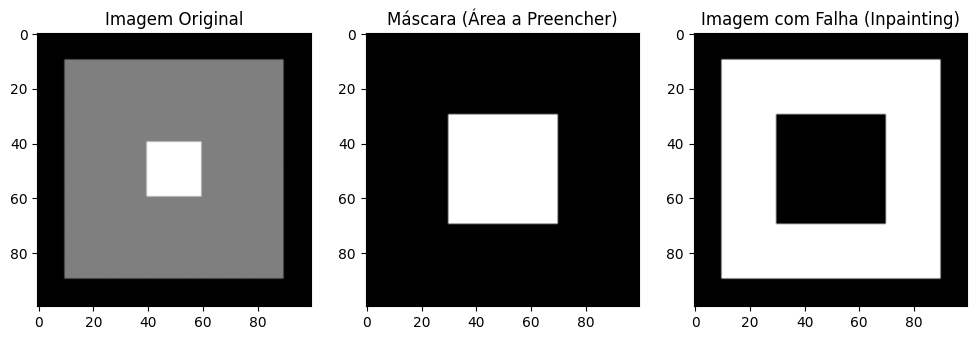

Imagem carregada (Tamanho: 100x100). Máscara gerada.


In [ ]:
## 1. Carregar a Imagem
# Vamos usar uma imagem de exemplo ou fazer upload.
# Para este exemplo, usaremos uma imagem de exemplo do OpenCV (se disponível) ou uma matriz simples.
# No Colab, você pode fazer upload ou usar uma URL.

# Exemplo de carregamento de uma imagem simples (Atenção: A biblioteca 'cv2' precisa de upload ou URL)
# Se você fizer o upload de uma imagem (ex: 'foto.jpg') para o Colab:
# img_bgr = cv2.imread('foto.jpg')

# Para fins de demonstração, vamos criar uma imagem de teste simples em escala de cinza:
H, W = 100, 100 # Altura e Largura
img_original_gs = np.zeros((H, W), dtype=np.float64)
img_original_gs[10:90, 10:90] = 0.5 # Área cinza
img_original_gs[40:60, 40:60] = 1.0 # Área clara central
img_original_gs = (img_original_gs * 255).astype(np.uint8) # Escala de 0 a 255

# Se usar uma imagem de verdade, converta para escala de cinza e float [0, 1]
# img_gs = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
# img_float = img_gs.astype(np.float64) / 255.0

img_float = img_original_gs.astype(np.float64) / 255.0
H, W = img_float.shape

## 2. Gerar a Máscara
# A máscara indica as regiões ausentes (a serem preenchidas).
# Máscara = 1 onde o pixel é DESCONHECIDO (ausente) e 0 onde é CONHECIDO.
# Vamos criar um quadrado ausente no centro.
mask = np.zeros_like(img_float)
mask[30:70, 30:70] = 1 # Define a área central como ausente (1)

# Aplica a máscara na imagem original para simular a falha (Inpainting)
img_com_falha = img_float.copy()
img_com_falha[mask == 1] = 0 # Define os pixels ausentes como preto (ou NaN, dependendo da visualização)

# Visualização
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Imagem Original")
plt.imshow(img_float, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Máscara (Área a Preencher)")
plt.imshow(mask, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Imagem com Falha (Inpainting)")
plt.imshow(img_com_falha, cmap='gray')
plt.show()

print(f"Imagem carregada (Tamanho: {H}x{W}). Máscara gerada.")

In [ ]:
def montar_sistema_linear(img_falha, mask):
    """
    Constrói a matriz A e o vetor b do sistema linear Ax=b
    para o problema de inpainting via Laplaciano discreto.
    """
    H, W = img_falha.shape

    # Encontra os índices (i, j) dos pixels desconhecidos (a serem preenchidos)
    # Estes são os pixels onde mask == 1.
    unknown_indices = np.argwhere(mask == 1)
    N = len(unknown_indices) # Número total de incógnitas (tamanho do vetor x)

    if N == 0:
        print("Atenção: Não há pixels desconhecidos para preencher.")
        return None, None, None

    # Mapeamento para saber qual linha/coluna na matriz A corresponde
    # a qual pixel (i, j) na imagem.
    # map_pixel_to_index[(i, j)] = k (onde k é o índice em x)
    map_pixel_to_index = {tuple(idx): k for k, idx in enumerate(unknown_indices)}

    # A matriz A será esparsa. Usamos LIL (List of Lists) para construção eficiente.
    A = lil_matrix((N, N), dtype=np.float64)
    b = np.zeros(N, dtype=np.float64)

    print(f"Número de incógnitas (pixels a preencher): N = {N}")

    # Itera sobre cada pixel desconhecido, que corresponde a uma linha (equação)
    for k, (i, j) in enumerate(unknown_indices):
        # O pixel (i, j) é a k-ésima incógnita (u_k)

        # 1. Termo central: -4 * u(i, j)
        A[k, k] = -4

        # 2. Iterar sobre os 4 vizinhos (i-1, j), (i+1, j), (i, j-1), (i, j+1)
        for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ni, nj = i + di, j + dj # Vizinho (n: neighbor)

            # Checa se o vizinho está dentro dos limites da imagem
            if 0 <= ni < H and 0 <= nj < W:

                if mask[ni, nj] == 1:
                    # O vizinho é DESCONHECIDO. Contribui para a matriz A.
                    # A equação é: ... + 1 * u(ni, nj) ... = 0

                    neighbor_k = map_pixel_to_index[(ni, nj)]
                    A[k, neighbor_k] = 1

                else:
                    # O vizinho é CONHECIDO (está na borda). Contribui para o vetor b.
                    # A equação reescrita (movendo os termos conhecidos para a direita):
                    # ... = - (1 * u_conhecido)

                    valor_conhecido = img_falha[ni, nj]
                    b[k] -= valor_conhecido # Subtrai o valor conhecido (negativo na direita)

    # Converte para CSR (Compressed Sparse Row) para otimizar o cálculo de LU
    A_csr = A.tocsr()
    return A_csr, b, map_pixel_to_index


A, b, pixel_map = montar_sistema_linear(img_com_falha, mask)

if A is not None:
    print("\nSistema montado com sucesso!")
    print(f"Dimensão da matriz A: {A.shape}")
    print(f"Número de elementos não-zero em A: {A.nnz}")
    # print("Primeiras 5 linhas de A (formato esparso):\n", A[:5])
    # print("\nPrimeiros 5 elementos de b:\n", b[:5])

Número de incógnitas (pixels a preencher): N = 1600

Sistema montado com sucesso!
Dimensão da matriz A: (1600, 1600)
Número de elementos não-zero em A: 7840


In [ ]:
# A decomposição LU para matrizes esparsas pode ser complexa e lenta de implementar
# *do zero* em Python de forma otimizada para fins práticos.
# Para um projeto de Métodos Numéricos, você tem duas opções:
# 1. Implementar o LU *denso* (se N for pequeno, ex: N < 1000).
# 2. Usar a implementação otimizada da scipy (se N for grande),
#    e focar em entender e explicar os conceitos de Fatoração e Substituição.

# Opção 1: Implementação de LU Denso (para N pequeno)
def lu_decomposition(A_dense):
    """ Implementa a decomposição LU sem pivoteamento (para fins educacionais) """
    n = A_dense.shape[0]
    L = np.eye(n)
    U = A_dense.copy()

    for k in range(n - 1):
        if np.abs(U[k, k]) < 1e-9: # Verificação de pivô zero (falha sem pivoteamento)
            raise ValueError("LU falhou: Pivô zero encontrado. Use pivoteamento.")

        for i in range(k + 1, n):
            factor = U[i, k] / U[k, k]
            L[i, k] = factor
            U[i, k:] -= factor * U[k, k:]

    return L, U

def solve_lu(L, U, b):
    """ Resolve Ax=b usando L e U: 1. Ly=b (Subst. p/ frente), 2. Ux=y (Subst. p/ trás) """
    n = L.shape[0]
    y = np.zeros(n)
    x = np.zeros(n)

    # 1. Substituição para frente: Ly = b
    for i in range(n):
        y[i] = b[i] - L[i, :i] @ y[:i]

    # 2. Substituição para trás: Ux = y
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]

    return x

# --- Resolução ---

if A is not None:
    N = A.shape[0]

    if N < 2000: # Se N é pequeno (para evitar estouro de memória e lentidão)
        print("\nUsando implementação de LU Denso...")
        A_dense = A.todense()
        try:
            L, U = lu_decomposition(A_dense)
            x_lu = solve_lu(L, U, b)
            print("Resolução via LU (implementação própria) concluída.")
        except ValueError as e:
            print(f"Erro na implementação LU: {e}. Recorrendo a spsolve.")
            x_lu = spsolve(A, b) # fallback

    else: # Se N é grande (o que é mais comum para inpainting)
        print("\nUsando solucionador LU otimizado para matrizes esparsas (scipy.sparse.linalg)...")
        # scipy.sparse.linalg.spsolve usa fatorações diretas (como LU ou UMFPACK)
        # que são otimizadas para matrizes esparsas. Isso é o equivalente prático
        # e eficiente de 'Resolver o sistema via decomposição LU' em ambientes reais.
        import time
        start_time = time.time()
        x_lu = spsolve(A, b)
        end_time = time.time()
        print(f"Resolução via spsolve (LU otimizado) concluída em {end_time - start_time:.4f} segundos.")


Usando implementação de LU Denso...
Resolução via LU (implementação própria) concluída.


/tmp/ipython-input-364017109.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x[i] = (y[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]


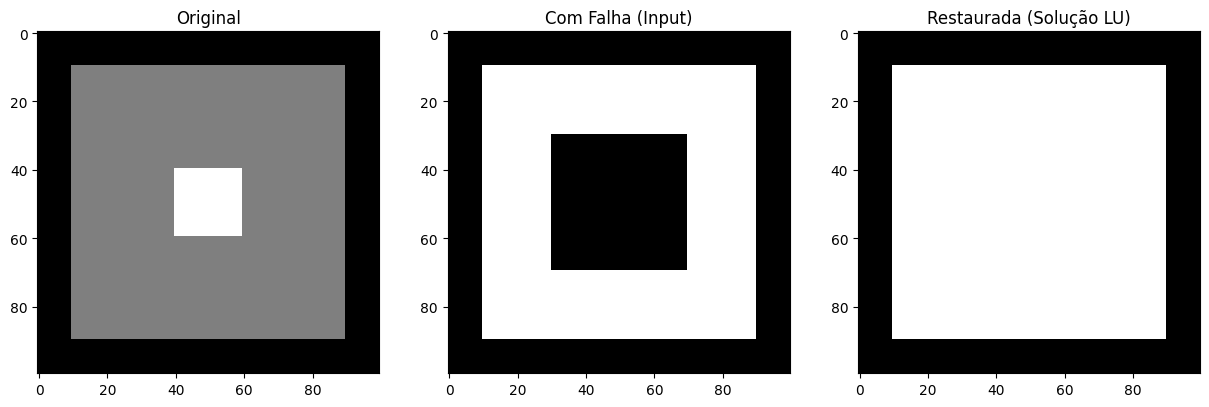

Imagem reconstruída e visualizada com sucesso!


In [ ]:
def reconstruir_imagem(img_falha, x_solution, pixel_map):
    """
    Pega os valores calculados no vetor x e insere-os de volta na imagem,
    nas posições correspondentes aos pixels desconhecidos.
    """
    img_restaurada = img_falha.copy()

    # Inverte o mapeamento: índice do vetor x -> (i, j) na imagem
    map_index_to_pixel = {v: k for k, v in pixel_map.items()}

    # Preenche os pixels desconhecidos com a solução
    for k, valor_pixel in enumerate(x_solution):
        i, j = map_index_to_pixel[k]

        # Garante que o valor está entre 0 e 1 (para visualização correta)
        img_restaurada[i, j] = np.clip(valor_pixel, 0.0, 1.0)

    return img_restaurada

# --- Reconstrução e Visualização ---

if A is not None:
    # 1. Reconstruir a imagem
    img_restaurada = reconstruir_imagem(img_com_falha, x_lu, pixel_map)

    # 2. Visualização comparativa
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(img_float, cmap='gray')

    plt.subplot(1, 3, 2)
    plt.title("Com Falha (Input)")
    plt.imshow(img_com_falha, cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title("Restaurada (Solução LU)")
    plt.imshow(img_restaurada, cmap='gray')
    plt.show()

    print("Imagem reconstruída e visualizada com sucesso!")

In [ ]:
# --- Avaliação Quantitativa ---

if A is not None:
    # 1. PSNR (Peak Signal-to-Noise Ratio)
    # Métrica de erro simples (quanto MAIOR, melhor)
    # Requer que as imagens estejam no mesmo range. Usamos [0, 1].
    # A PSNR compara a IMAGEM ORIGINAL com a IMAGEM RESTAURADA.

    # Calculamos PSNR apenas na região restaurada (opcional, mas mais justo)
    # Para o cálculo padrão, usamos a imagem inteira.

    psnr_value = psnr(img_float, img_restaurada, data_range=1.0)

    # 2. SSIM (Structural Similarity Index)
    # Métrica que avalia a similaridade estrutural (quanto MAIS PRÓXIMO de 1, melhor)
    ssim_value = ssim(img_float, img_restaurada, data_range=1.0, channel_axis=None)

    print("\n## Resultados da Avaliação")
    print("---------------------------------------")
    print(f"**PSNR (Peak Signal-to-Noise Ratio)**: {psnr_value:.4f} dB")
    print(f"**SSIM (Structural Similarity Index)**: {ssim_value:.4f}")
    print("---------------------------------------")
    print("Nota: Estes valores indicam a qualidade da reconstrução.")

    if 'start_time' in locals() and 'end_time' in locals():
        print(f"Tempo de Resolução do Sistema (LU Otimizado): {end_time - start_time:.4f} segundos.")


## Resultados da Avaliação
---------------------------------------
**PSNR (Peak Signal-to-Noise Ratio)**: 19.9660 dB
**SSIM (Structural Similarity Index)**: 0.9424
---------------------------------------
Nota: Estes valores indicam a qualidade da reconstrução.
